# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Ana Sittah Rosyidah, S.ST.
- Email: ana5210@guru.smk.belajar.id
- Id Dicoding:https://www.dicoding.com/users/ana_sittah_rosyidah/academies

## Persiapan

#### 1. Pemahaman Variabel Kunci
Dari data tersebut, ada beberapa faktor krusial yang biasanya menjadi penyebab utama dropout:

* Faktor Akademik: Curricular_units_..._approved dan ..._grade. Jika jumlah mata kuliah yang lulus di semester 1  rendah, risiko dropout biasanya melonjak.

* Faktor Ekonomi: Debtor (apakah punya utang), Tuition_fees_up_to_date (pembayaran uang kuliah), dan Scholarship_holder.

* Faktor Demografi: Age_at_enrollment (mahasiswa yang lebih tua seringkali memiliki tanggung jawab lain) dan Displaced (mahasiswa yang tinggal jauh dari rumah).

* Faktor Makroekonomi: Unemployment_rate dan GDP di masa tersebut.

### 2. Strategi Analisis Data (EDA)
Sebelum membuat model prediksi, kita perlu melakukan visualisasi untuk menemukan "Red Flags":

* Korelasi Nilai vs Status: Apakah mahasiswa dengan nilai di bawah 10 (Curricular_units_grade) hampir pasti akan dropout?

* Analisis Finansial: Seberapa besar pengaruh tunggakan SPP (Tuition_fees_up_to_date = 0) terhadap keputusan berhenti kuliah?

* Perbandingan Gender: Apakah ada tren tertentu pada jenis kelamin tertentu?

### 3. Pengembangan Model Prediksi
Kita akan membangun model Machine Learning (seperti Random Forest atau XGBoost) yang bisa memberikan label:

* Graduate: Mahasiswa yang kemungkinan besar lulus.

* Dropout: Mahasiswa yang berisiko tinggi berhenti.

* Enrolled: Mahasiswa yang masih dalam pemantauan.

Output Model: Sebuah sistem skor risiko. Jika seorang mahasiswa baru selesai semester 1 dan memiliki skor risiko > 70%, sistem akan memberikan peringatan kepada bagian bimbingan konseling.

### 4. Perancangan Dashboard
Untuk memudahkan manajemen Jaya Jaya Institut, dashboard akan dibagi menjadi tiga bagian utama:

| Section | Metrik Utama | Visualisasi |
| :--- | :--- | :--- |
| **Ringkasan Eksekutif** | Total Mahasiswa, % Dropout Rate | Gauge Chart (Indikator Bahaya) |
| **Performa Akademik** | Rata-rata IPK per Semester | Heatmap kelulusan mata kuliah |
| **Profil Risiko** | Daftar Mahasiswa "High Risk" | Tabel interaktif dengan filter jurusan |
| **Faktor Sosial-Ekonomi** | Pengaruh Beasiswa & Status Ekonomi | Bar chart perbandingan status |

### Menyiapkan library yang dibutuhkan

In [64]:
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import sqlalchemy
import sklearn
import joblib

### Menyiapkan data yang akan diguankan

## Data Understanding

#### Daftar Fitur Dataset Jaya Jaya Institut

#### 1. Data Demografi & Sosial
* **Marital_status**: Status pernikahan mahasiswa saat mendaftar.
* **Nacionality**: Kewarganegaraan mahasiswa.
* **Displaced**: Status domisili (apakah mahasiswa merantau dari daerah asal).
* **Gender**: Jenis kelamin mahasiswa.
* **Age_at_enrollment**: Usia mahasiswa pada saat melakukan pendaftaran.
* **International**: Indikator apakah mahasiswa merupakan pelajar internasional.

#### 2. Data Latar Belakang Pendidikan & Keluarga
* **Previous_qualification**: Kualifikasi pendidikan terakhir sebelum masuk perguruan tinggi.
* **Previous_qualification_grade**: Nilai rata-rata dari kualifikasi pendidikan sebelumnya.
* **Mothers_qualification / Fathers_qualification**: Tingkat pendidikan tertinggi ibu dan ayah.
* **Mothers_occupation / Fathers_occupation**: Bidang pekerjaan ibu dan ayah.

#### 3. Data Pendaftaran (Enrollment)
* **Application_mode**: Jalur atau metode pendaftaran yang digunakan.
* **Application_order**: Urutan prioritas jurusan yang dipilih oleh mahasiswa (1, 2, dst).
* **Course**: Program studi atau jurusan yang sedang ditempuh.
* **Daytime_evening_attendance**: Waktu kehadiran perkuliahan (kelas pagi/siang atau kelas malam).
* **Admission_grade**: Nilai hasil seleksi masuk perguruan tinggi.

#### 4. Data Status Ekonomi & Fasilitas
* **Educational_special_needs**: Indikator apakah mahasiswa memiliki kebutuhan pendidikan khusus.
* **Debtor**: Status apakah mahasiswa memiliki tunggakan hutang kepada institusi.
* **Tuition_fees_up_to_date**: Status kelancaran pembayaran uang kuliah.
* **Scholarship_holder**: Indikator apakah mahasiswa merupakan penerima beasiswa.

#### 5. Data Akademik (Semester 1 & Semester 2)
*Fitur ini mencakup variabel yang sama untuk unit kurikuler di Semester 1 dan Semester 2:*
* **Credited**: Jumlah mata kuliah yang dikonversi/diakui.
* **Enrolled**: Jumlah mata kuliah yang diambil/didaftarkan.
* **Evaluations**: Jumlah evaluasi atau ujian yang diikuti.
* **Approved**: Jumlah mata kuliah yang berhasil dinyatakan lulus.
* **Grade**: Rata-rata nilai akademik yang diperoleh.
* **Without_evaluations**: Jumlah mata kuliah yang diambil namun tidak memiliki komponen evaluasi.

#### 6. Data Makroekonomi & Target
* **Unemployment_rate**: Tingkat pengangguran di wilayah/negara pada periode tersebut.
* **Inflation_rate**: Tingkat inflasi pada periode terkait.
* **GDP**: Pertumbuhan Produk Domestik Bruto (PDB).
* **Status (Target)**: Label klasifikasi mahasiswa ( **Dropout**, **Graduate**, atau **Enrolled** ).

In [65]:
df = pd.read_csv("students_performance/data.csv")

In [66]:
# Pastikan menyertakan sep=';'
df = pd.read_csv('students_performance/data.csv', sep=';')

# Sekarang df.head(10) akan muncul dengan rapi
df.head(10)

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,1,18,4,9254,1,1,119.0,1,37,37,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,1,1,3,9238,1,1,137.0,62,1,1,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,1,1,1,9238,1,1,138.0,1,1,19,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

## Data Preparation / Preprocessing

### Bagian 1: Data Understanding & Cleaning

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data (Gunakan sep=';' karena data Anda menggunakan titik koma)
df = pd.read_csv('students_performance/data.csv', sep=';')

# 2. Pembersihan Dasar
# Cek apakah ada data kosong (NaN)
print("Jumlah Missing Values:\n", df.isnull().sum().sum())

# Cek Duplikasi
print("Jumlah Duplikasi:", df.duplicated().sum())

# Cek tipe data
# df.info() 

# Tips: Pastikan target 'Status' bersih dari spasi tambahan
df['Status'] = df['Status'].str.strip()

Jumlah Missing Values:
 0
Jumlah Duplikasi: 0


### Bagian 2: Exploratory Data Analysis (EDA)
#### 2.1. Rangkuman Statistik

In [69]:
# Deskripsi statistik untuk kolom numerik
print(df.describe())

# Melihat distribusi target (Berapa banyak yang Dropout vs Graduate)
print(df['Status'].value_counts(normalize=True) * 100)

       Marital_status  Application_mode  Application_order       Course  \
count     4424.000000       4424.000000        4424.000000  4424.000000   
mean         1.178571         18.669078           1.727848  8856.642631   
std          0.605747         17.484682           1.313793  2063.566416   
min          1.000000          1.000000           0.000000    33.000000   
25%          1.000000          1.000000           1.000000  9085.000000   
50%          1.000000         17.000000           1.000000  9238.000000   
75%          1.000000         39.000000           2.000000  9556.000000   
max          6.000000         57.000000           9.000000  9991.000000   

       Daytime_evening_attendance  Previous_qualification  \
count                 4424.000000             4424.000000   
mean                     0.890823                4.577758   
std                      0.311897               10.216592   
min                      0.000000                1.000000   
25%                

#### 2.2. Membuat Helper Function (Efisiensi Kode)

In [70]:
def plot_categorical_vs_target(data, feature, target='Status'):
    """Fungsi untuk melihat proporsi status berdasarkan fitur kategorikal"""
    plt.figure(figsize=(10, 5))
    sns.countplot(data=data, x=feature, hue=target, palette='viridis')
    plt.title(f'Distribusi {target} berdasarkan {feature}')
    plt.xticks(rotation=45)
    plt.show()

def plot_numerical_distribution(data, feature, target='Status'):
    """Fungsi untuk melihat distribusi nilai numerik terhadap target"""
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=data, x=target, y=feature, palette='Set2')
    plt.title(f'Perbandingan {feature} terhadap {target}')
    plt.show()

#### 2.3. Eksekusi Perbandingan Massal

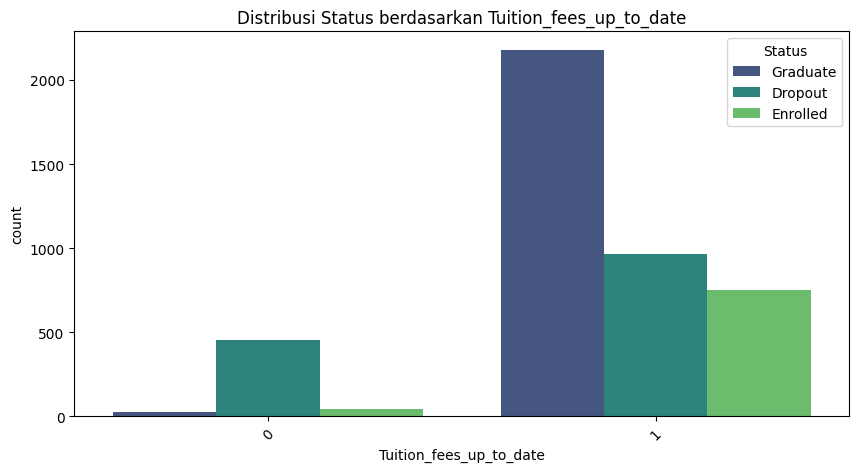

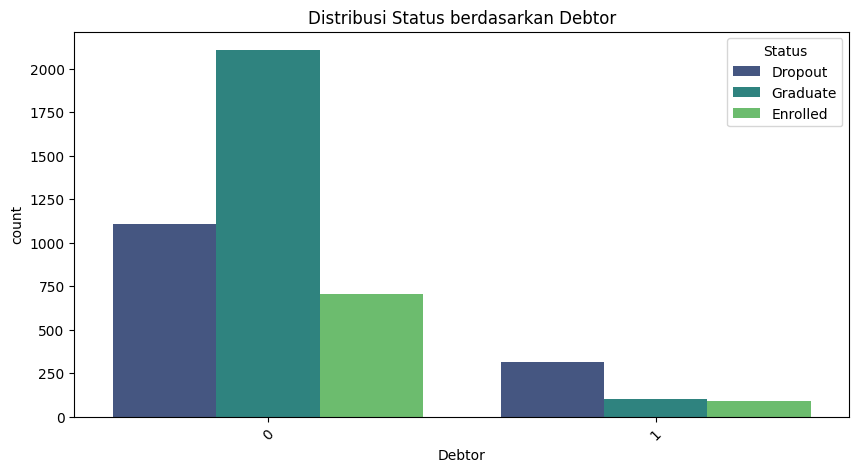

/var/folders/mh/g9f2v_2551zf9rxl16hn8sy40000gn/T/ipykernel_27285/232825646.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=feature, palette='Set2')


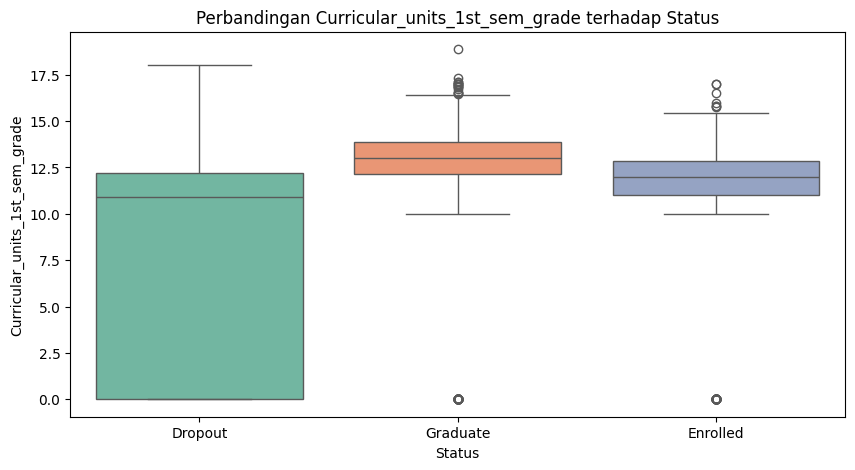

/var/folders/mh/g9f2v_2551zf9rxl16hn8sy40000gn/T/ipykernel_27285/232825646.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=feature, palette='Set2')


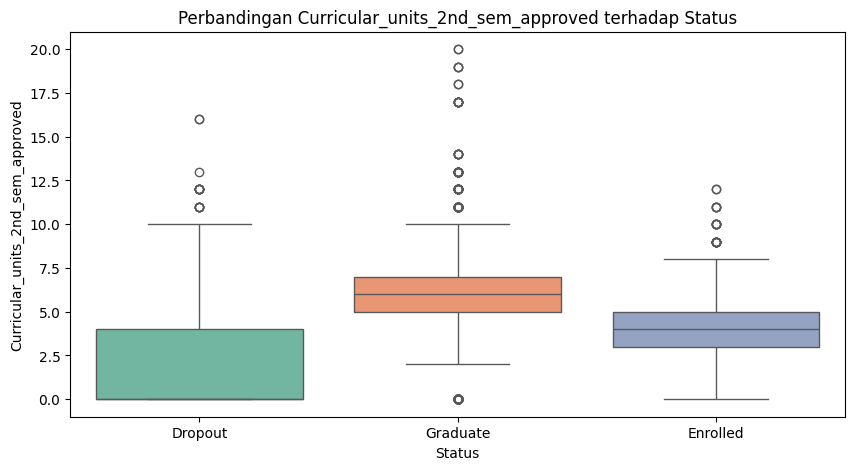

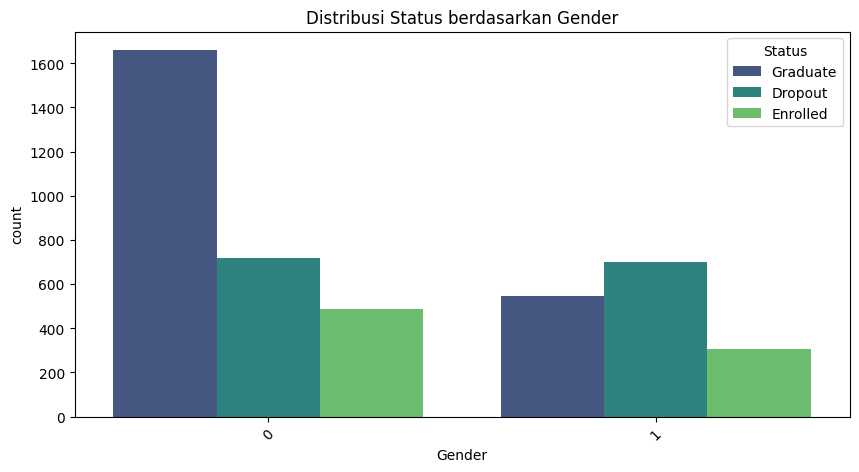

In [71]:
# EDA Berdasarkan Kelompok Fitur yang Anda buat:

# A. Masalah Finansial (Red Flag 1)
plot_categorical_vs_target(df, 'Tuition_fees_up_to_date')
plot_categorical_vs_target(df, 'Debtor')

# B. Masalah Akademik (Red Flag 2)
plot_numerical_distribution(df, 'Curricular_units_1st_sem_grade')
plot_numerical_distribution(df, 'Curricular_units_2nd_sem_approved')

# C. Faktor Demografi (Red Flag 3)
plot_categorical_vs_target(df, 'Gender')

### Bagian 3: Analisis (Feature Engineering & Transformation)

In [72]:
# 1. Encoding Target
# Mengubah Dropout, Graduate, Enrolled menjadi angka
status_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Status_Label'] = df['Status'].map(status_map)

# 2. Mengelompokkan Usia (Opsional, tapi membantu insight)
df['Age_Group'] = pd.cut(df['Age_at_enrollment'], 
                         bins=[0, 20, 30, 45, 100], 
                         labels=['Remaja', 'Dewasa Muda', 'Dewasa', 'Senior'])

### Bagian 4: Korelasi & Insight Tambahan

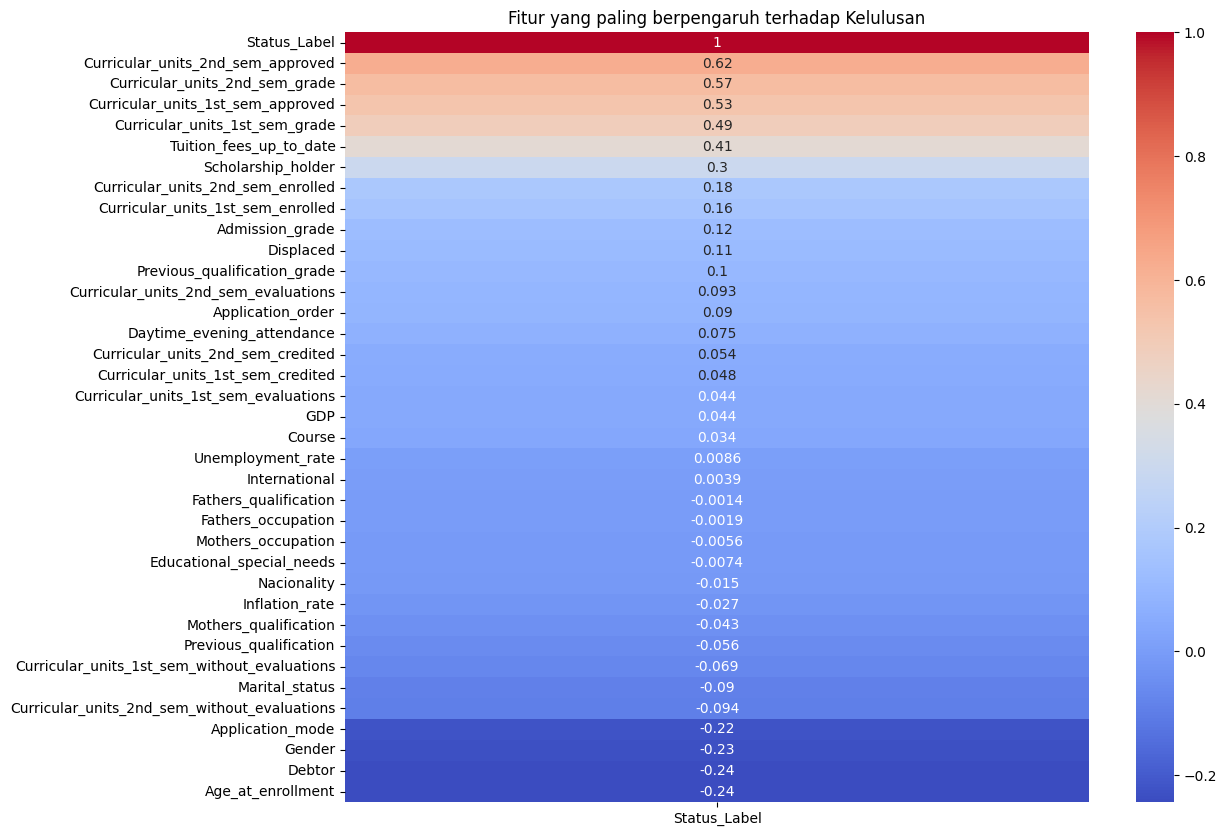

Top 5 Faktor Pendukung Kelulusan:
 Status_Label                         1.000000
Curricular_units_2nd_sem_approved    0.624157
Curricular_units_2nd_sem_grade       0.566827
Curricular_units_1st_sem_approved    0.529123
Curricular_units_1st_sem_grade       0.485207
Tuition_fees_up_to_date              0.409827
Name: Status_Label, dtype: float64

Top 5 Faktor Pemicu Dropout (Korelasi Negatif):
 Curricular_units_2nd_sem_without_evaluations   -0.094028
Application_mode                               -0.221747
Gender                                         -0.229270
Debtor                                         -0.240999
Age_at_enrollment                              -0.243438
Name: Status_Label, dtype: float64


In [73]:
# Menghitung korelasi kolom numerik terhadap Status_Label
plt.figure(figsize=(12, 10))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()

# Tampilkan hanya korelasi terhadap target
target_corr = correlation_matrix['Status_Label'].sort_values(ascending=False)

sns.heatmap(target_corr.to_frame(), annot=True, cmap='coolwarm')
plt.title("Fitur yang paling berpengaruh terhadap Kelulusan")
plt.show()

print("Top 5 Faktor Pendukung Kelulusan:\n", target_corr.head(6))
print("\nTop 5 Faktor Pemicu Dropout (Korelasi Negatif):\n", target_corr.tail(5))

## Modeling

### Step 1: Persiapan Data (Feature & Target)

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
# Ganti confidence_score menjadi accuracy_score
from sklearn.metrics import classification_report, accuracy_score 
import joblib

# 1. Pilih fitur (X) dan target (y)
# Kita hapus 'Status' dan 'Status_Label' dari X
X = df.drop(columns=['Status', 'Status_Label', 'Age_Group']) 
y = df['Status_Label']

# 2. Split data: 80% untuk latihan, 20% untuk pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data latihan: {X_train.shape[0]} baris")
print(f"Data pengujian: {X_test.shape[0]} baris")

Data latihan: 3539 baris
Data pengujian: 885 baris


### Step 2: Training Model

In [75]:
# 3. Inisialisasi dan Training Model
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# 4. Evaluasi Singkat
y_pred = model.predict(X_test)
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred, target_names=['Dropout', 'Enrolled', 'Graduate']))


Laporan Klasifikasi:
               precision    recall  f1-score   support

     Dropout       0.82      0.76      0.79       284
    Enrolled       0.58      0.37      0.45       159
    Graduate       0.79      0.93      0.85       442

    accuracy                           0.78       885
   macro avg       0.73      0.69      0.70       885
weighted avg       0.76      0.78      0.76       885



### Step 3: Membuat Sistem Skor Risiko (Probability)

In [76]:
# Ambil probabilitas untuk data pengujian
# predict_proba menghasilkan array [prob_0, prob_1, prob_2]
probabilities = model.predict_proba(X_test)

# Ambil probabilitas khusus untuk 'Dropout' (Indeks 0)
dropout_risk_scores = probabilities[:, 0]

# Tambahkan logika peringatan (Alert)
X_test_with_score = X_test.copy()
X_test_with_score['Dropout_Risk_Score'] = dropout_risk_scores
X_test_with_score['Alert'] = X_test_with_score['Dropout_Risk_Score'] > 0.7

print("\nContoh Mahasiswa dengan Risiko Tinggi (>70%):")
print(X_test_with_score[X_test_with_score['Alert'] == True].head())


Contoh Mahasiswa dengan Risiko Tinggi (>70%):
      Marital_status  Application_mode  Application_order  Course  \
1864               1                 1                  1    9130   
1717               2                39                  1    9500   
723                1                39                  1    8014   
482                1                 1                  3    9500   
4220               1                 1                  1    9670   

      Daytime_evening_attendance  Previous_qualification  \
1864                           1                       1   
1717                           1                       1   
723                            0                       1   
482                            1                       1   
4220                           1                       1   

      Previous_qualification_grade  Nacionality  Mothers_qualification  \
1864                         140.0            1                      9   
1717                         

### Step 4: Menyimpan Model ke File .joblib

In [77]:
# 5. Simpan Model dan daftar kolom (penting agar input dashboard nanti urutannya sama)
model_data = {
    'model': model,
    'features': X.columns.tolist(),
    'target_mapping': {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}
}

joblib.dump(model_data, 'model/model_jaya_jaya_institut.joblib')
print("\nModel berhasil disimpan sebagai 'model_jaya_jaya_institut.joblib'")


Model berhasil disimpan sebagai 'model_jaya_jaya_institut.joblib'


## Evaluation

### 1. Confusion Matrix (Melihat Detail Kesalahan)

<Figure size 800x600 with 0 Axes>

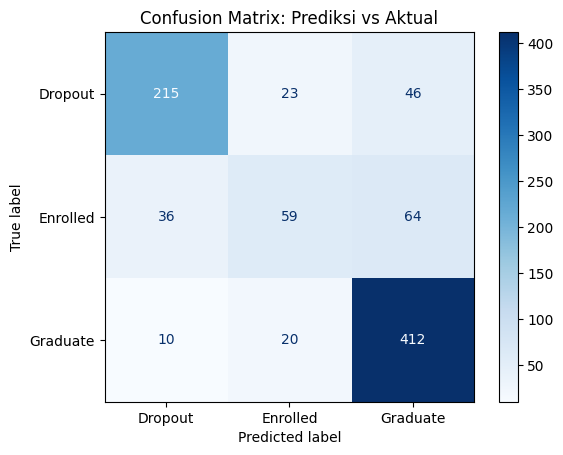

In [78]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Membuat matriks kesalahan
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                              display_labels=['Dropout', 'Enrolled', 'Graduate'])

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues')
plt.title('Confusion Matrix: Prediksi vs Aktual')
plt.show()

### 2. Feature Importance (Faktor Pemicu Utama)

/var/folders/mh/g9f2v_2551zf9rxl16hn8sy40000gn/T/ipykernel_27285/3225514571.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')


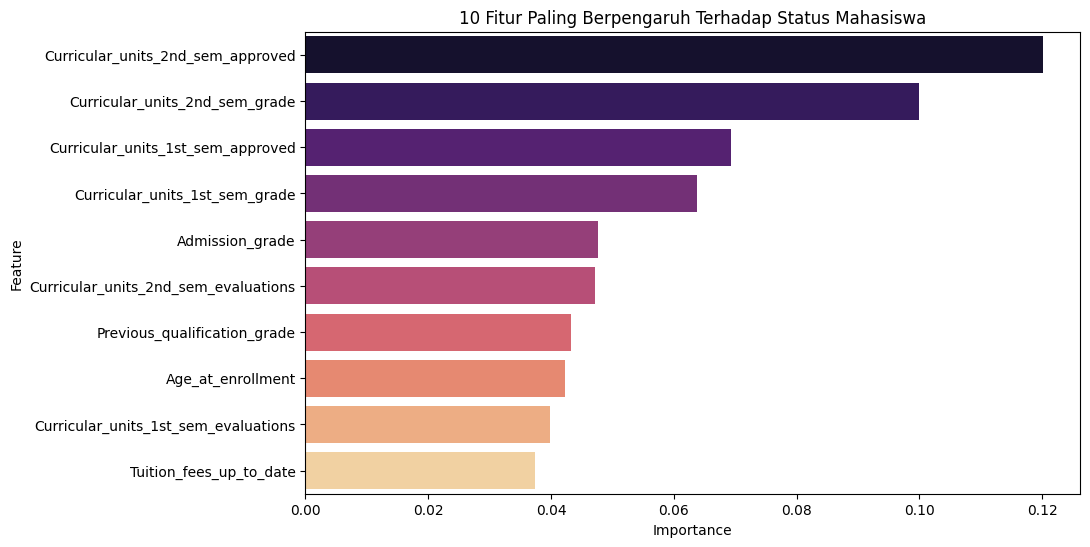

In [79]:
# Mengambil tingkat kepentingan fitur
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualisasi 10 Fitur Teratas
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')
plt.title('10 Fitur Paling Berpengaruh Terhadap Status Mahasiswa')
plt.show()

### 3. ROC-AUC Curve (Mengukur Kemampuan Membedakan Kelas)

In [80]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelBinarizer

# Karena ini multi-class (3 label), kita perlu binarize labelnya
lb = LabelBinarizer()
y_test_binarized = lb.fit_transform(y_test)
y_score = model.predict_proba(X_test)

# Menghitung AUC Score
auc_score = roc_auc_score(y_test_binarized, y_score, multi_class='ovr')
print(f"Rata-rata Skor ROC-AUC Model: {auc_score:.4f}")

Rata-rata Skor ROC-AUC Model: 0.8842


### 4. Cross-Validation (Uji Konsistensi)

In [81]:
from sklearn.model_selection import cross_val_score

# Melakukan 5-Fold Cross Validation
cv_scores = cross_val_score(model, X, y, cv=5)

print(f"Skor Akurasi tiap Fold: {cv_scores}")
print(f"Rata-rata Akurasi (Cross-Val): {cv_scores.mean():.4f}")
print(f"Standar Deviasi (Konsistensi): {cv_scores.std():.4f}")

Skor Akurasi tiap Fold: [0.77175141 0.77740113 0.77966102 0.77853107 0.77036199]
Rata-rata Akurasi (Cross-Val): 0.7755
Standar Deviasi (Konsistensi): 0.0038
